# No. of Crews vs Objective Function

This notebook plots the relationship between the **number of repair crews** and one selected objective function for the damage scenarios.

The objective function can be selected in one cell, and the plot updates automatically.

The input data are read from `results_best_solutions.xlsx`.


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load results
file_path = "results_best_solutions.xlsx"
df = pd.read_excel(file_path)

# Display the first rows to verify the data
df.head()


,Damage scenario,No. crews,FH (min),t95 (min),RL (%-min),TNS (min),NWSECH,WL (m^3),Solution
0,DS2,1,120,37140,83593.17,69.80,25,479589.96,G48 S83
1,DS2,3,0,11220,28610.48,28.31,18,149723.58,G39 S45
2,DS2,15,0,1200,5164.52,11.20,8,22683.55,G44 S46
3,DS2,30,0,180,2943.85,10.13,7,8212.15,G31 S64
4,DS2,45,0,180,2250.17,9.75,5,3458.40,G20 S45


## Select the objective function

Choose **one** of the six objective functions below.

Available objectives:

- `FH (min)`
- `t95 (min)`
- `RL (%-min)`
- `TNS (min)`
- `NWSECH`
- `WL (m^3)`


In [92]:
# Select the objective function to plot
objective = "WL (m^3)"

# Available objective functions
objectives = [
    "FH (min)",
    "t95 (min)",
    "RL (%-min)",
    "TNS (min)",
    "NWSECH",
    "WL (m^3)"
]

# Check that the selected objective is valid
if objective not in objectives:
    raise ValueError(
        f"Invalid objective. Choose one of: {objectives}"
    )


## Objective labels and units

These labels are used automatically for the plot so that the selected objective is displayed clearly.

In [93]:
# Display label for each objective
objective_labels = {
    "FH (min)": "FH (min)",
    "t95 (min)": "t95 (min)",
    "RL (%-min)": "Resilience loss (%-min)",
    "TNS (min)": "Time no service (min)",
    "NWSECH": "NWSECH",
    "WL (m^3)": "Water loss (m³)"
}

y_label = objective_labels[objective]


## Damage scenario plot

The x-axis is treated as a **continuous numerical axis**, so the spacing between crew numbers represents the actual difference in the number of crews.

Markers are included because each point represents a simulated solution.

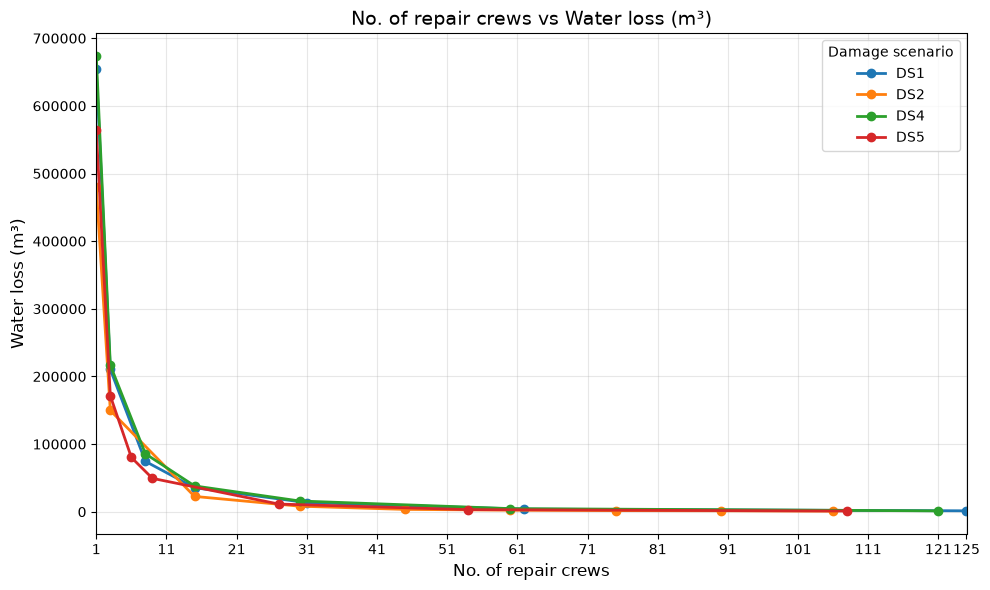

In [ ]:
# Plot selected objective vs number of repair crews for DS1, DS2, DS4 and DS5

# Damage scenarios
scenarios = ["DS1", "DS2", "DS4", "DS5"]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each damage scenario separately
for scenario in scenarios:
    
    # Filter data for the current damage scenario
    scenario_data = df[df["Damage scenario"].str.strip() == scenario].copy()
    
    # Sort by number of crews
    scenario_data = scenario_data.sort_values("No. crews")
    
    # Plot
    ax.plot(
        scenario_data["No. crews"],
        scenario_data[objective],
        marker="o",
        linewidth=2,
        markersize=6,
        label=scenario
    )


# X-axis: full range of possible crews
ax.set_xlim(1, 125)

# Integer crew values
ax.set_xticks(range(1, 126, 10))

# Make sure 125 is included as the final tick
ax.set_xticks(list(range(1, 126, 10)) + [125])

# Labels
ax.set_xlabel("No. of repair crews", fontsize=12)
ax.set_ylabel(y_label, fontsize=12)

# Title
ax.set_title(
    f"No. of repair crews vs {y_label}",
    fontsize=14
)

# Grid
ax.grid(True, alpha=0.3)

# Legend
ax.legend(
    title="Damage scenario"
)

# Layout
plt.tight_layout()

# Display
plt.show()

## Optional: save the figure

Run the following cell if you want to save the figure for your thesis.

In [95]:
# # Save figure
# output_file = f"crews_vs_{objective.replace(' ', '_').replace('/', '-')}.png"

# fig.savefig(
#     output_file,
#     dpi=300,
#     bbox_inches="tight"
# )

# print(f"Figure saved as: {output_file}")


### Improvement metrics
The block of code below generates the dataframes related to the improvement metrics of the previously selected 

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# SETTINGS
# ============================================================


selected_scenario = "DS5"


df["Damage scenario"] = df["Damage scenario"].astype(str).str.strip()

data_scenario = df[
    df["Damage scenario"] == selected_scenario
].copy()

data_scenario = data_scenario.sort_values("No. crews").reset_index(drop=True)



# CALCULATE THREE improvements: slope, relative improvement, and cumulative relative improvement

slope_values = {}
relative_improvement_values = {}
cumulative_improvement_values = {}

# 1-crew baseline
crews_initial = data_scenario.loc[0, "No. crews"]
objective_initial = data_scenario.loc[0, objective]


for i in range(1, len(data_scenario)):

    crews_before = data_scenario.loc[i - 1, "No. crews"]
    objective_before = data_scenario.loc[i - 1, objective]

    crews_after = data_scenario.loc[i, "No. crews"]
    objective_after = data_scenario.loc[i, objective]

    delta_crews = crews_after - crews_before

    range_label = f"{int(crews_before)} to {int(crews_after)}"


    # Check for missing objective values

    if pd.isna(objective_before) or pd.isna(objective_after):

        print(
            f"WARNING: Missing {selected_objective} value "
            f"for interval {range_label}"
        )

        slope_values[range_label] = np.nan
        relative_improvement_values[range_label] = np.nan

    else:


        # 1. SLOPE

        slope = (
            objective_after - objective_before
        ) / delta_crews

        slope_values[range_label] = slope

        # 2. RELATIVE IMPROVEMENT
        #    Based on the previous crew level

        relative_improvement = (
            (objective_before - objective_after)
            / objective_before
        ) * 100 

        relative_improvement_values[range_label] = (
            relative_improvement
        )

    # 3. CUMULATIVE RELATIVE IMPROVEMENT
    #    ALWAYS compared with the 1-crew baseline

    if pd.isna(objective_initial) or pd.isna(objective_after):

        cumulative_relative_improvement = np.nan

    else:

        cumulative_relative_improvement = (
            (objective_initial - objective_after)
            / objective_initial
        ) * 100

    cumulative_improvement_values[range_label] = (
        cumulative_relative_improvement
    )



# CREATE DATAFRAME

results_dataframe = pd.DataFrame(
    [
        slope_values,
        relative_improvement_values,
        cumulative_improvement_values
    ],
    index=[
        "Slope",
        "Relative improvement (%)",
        "Cumulative relative improvement (%)"
    ]
)

results_dataframe.index.name = "Measure"


# ROUND RESULTS

results_dataframe = results_dataframe.round(2)


# DISPLAY

display(results_dataframe)


# EXPORT

output_file = (
    f"crew_improvement_{selected_scenario}_"
    f"{selected_objective.split()[0]}.xlsx"
)

results_dataframe.to_excel(output_file)

print(f"Results exported to: {output_file}")

,1 to 3,3 to 6,6 to 9,9 to 27,27 to 54,54 to 108
Measure,,,,,,
Slope,-196291.36,-30381.86,-10296.86,-2110.12,-304.60,-38.79
Relative improvement (%),69.61,53.18,38.49,76.95,72.27,66.37
Cumulative relative improvement (%),69.61,85.77,91.25,97.98,99.44,99.81


Results exported to: crew_improvement_DS5_WL.xlsx
